#### Carga de datos

In [3]:
import kagglehub, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

# Obtengo el path donde fueron descargados los archivos
print("Path to dataset files:", path)

Path to dataset files: /home/vali0n/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1


In [4]:
# Listo los archivos descargados en el path en mi sistema para ver si se descargó todo correctamente
print("Ficheros descargados:", os.listdir(path))

Ficheros descargados: ['mitbih_train.csv', 'mitbih_test.csv', 'ptbdb_normal.csv', 'ptbdb_abnormal.csv']


In [5]:
# Obtengo los dataframes del path asociado a la cache de kagglehub en mi sistema concatenado con los nombres de los ficheros
df_train = pd.read_csv(os.path.join(path,"mitbih_train.csv"), header=None)
df_test = pd.read_csv(os.path.join(path,"mitbih_test.csv"), header=None)

# Compruebo que se han leido bien los datos
print("Primeras 5 observaciones de train:", df_train.head())
print("Primeras 5 observaciones de test:", df_test.head())


Primeras 5 observaciones de train:         0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.

### 2. Análisis exploratorio de datos

Se dispone de un conjunto de entrenamiento de 87554 registros con 188 valores numéricos de los cuales 187 son
características y 1 es la etiqueta de clase (normal o anómalo). El conjunto de prueba tiene 21892 con las mismas
características.

In [6]:
df_train.shape

(87554, 188)

In [7]:
df_test.shape

(21892, 188)

Sabiendo que ambos tienen la misma estructura, comienzo analizando los estadísticos descriptivos del conjunto de
entrenamiento.

              Clase     Media   Mediana  Moda  Varianza  Rango  P25       P75
0            Normal  0.161896  0.074303   0.0  0.047334    1.0  0.0  0.266430
1  Supraventricular  0.194778  0.147126   0.0  0.046066    1.0  0.0  0.333333
2       Ventricular  0.243849  0.210826   0.0  0.068824    1.0  0.0  0.397315
3            Fusión  0.107253  0.000000   0.0  0.037268    1.0  0.0  0.163313
4             Ruido  0.250854  0.181818   0.0  0.069859    1.0  0.0  0.467797


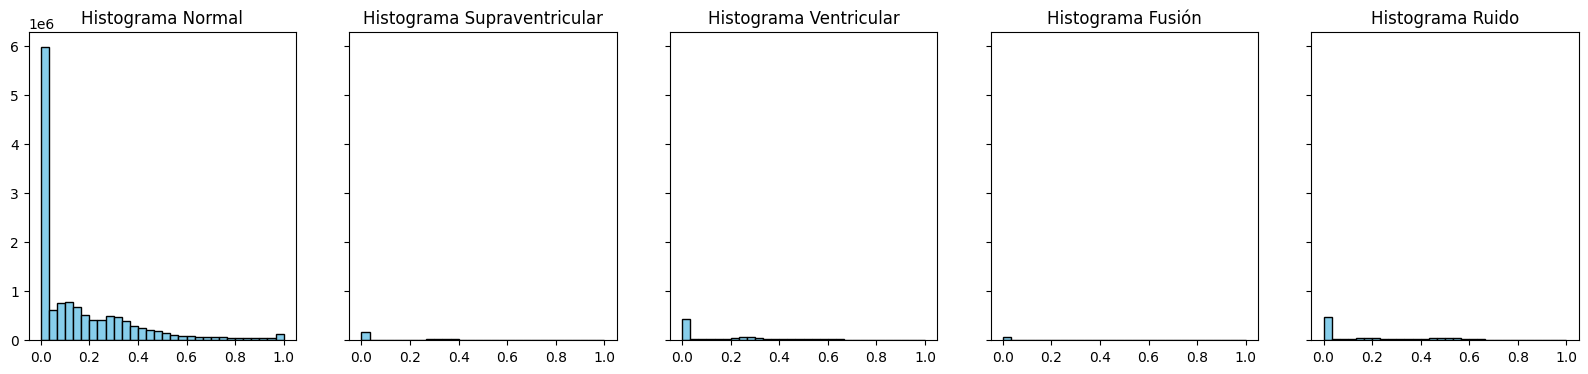

In [8]:
nombres_clases = {0: "Normal", 1: "Supraventricular", 2: "Ventricular", 3: "Fusión", 4: "Ruido"}

# Creo una tabla de estadísticos por clase
stats_list = []
for clase in sorted(df_train[187].unique()):
    data = df_train[df_train[187] == clase].iloc[:, :187].values.flatten()
    
    stats_list.append({
        'Clase': nombres_clases[clase],
        'Media': np.mean(data),
        'Mediana': np.median(data),
        'Moda': stats.mode(data, keepdims=True)[0][0],
        'Varianza': np.var(data),
        'Rango': np.ptp(data),
        'P25': np.percentile(data, 25),
        'P75': np.percentile(data, 75)
    })

df_stats = pd.DataFrame(stats_list)
print(df_stats)

# Histogramas de amplitud por clase
fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, clase in enumerate(sorted(df_train[187].unique())):
    data = df_train[df_train[187] == clase].iloc[:, :187].values.flatten()
    axs[i].hist(data, bins=30, color='skyblue', edgecolor='black')
    axs[i].set_title(f"Histograma {nombres_clases[clase]}")
plt.show()


#### 2.1 Distribución de las clases

Como dentro de la clasificación se encuentran 5 tipos, es necesario conocer la distribución de las clases en el conjunto para saber si existe un desbalanceo.

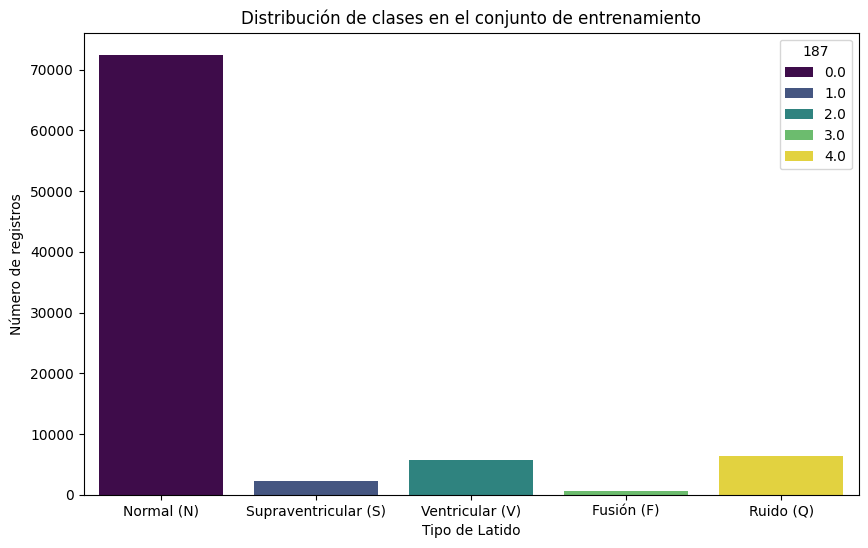

In [9]:
ticks = [0, 1, 2, 3, 4]
labels = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusión (F)', 'Ruido (Q)']

# Cuento cuántos registros hay de cada clase
counts = df_train[187].value_counts().sort_index()

# Creo el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts.values, palette="viridis", hue=counts.index, dodge=False)

# Añado etiquetas descriptivas según el dataset
plt.xticks(ticks=ticks, 
           labels=labels)

plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Tipo de Latido")
plt.ylabel("Número de registros")
plt.show()

In [10]:
# Hago un pequeño dataframe con los totales de registros por clase y su porcentaje
df_totales = pd.DataFrame({'Clase': counts.index,
                           'Número de registros': counts.values, 
                           'Porcentaje (%)': (counts.values / df_train.shape[0] * 100)}
)
df_totales

,Clase,Número de registros,Porcentaje (%)
0,0.0,72471,82.772917
1,1.0,2223,2.539005
2,2.0,5788,6.610777
3,3.0,641,0.732120
4,4.0,6431,7.345181


Como se pudo observar, existe una asimetría en la distribución de las clases, siendo la clase 0 (latido normal) la que más registros posee, con un 82,77% de los datos, mientras que la clase 3, latido de fusión, es la que menos
registros tiene, con apenas un 0.73% del total. Esto ha de ser considerado posteriormente en la confección del modelo, ya que un desbalanceo más grande puede favorecer a los casos de la clase mayoritaria, mermando así el rendimiento.

#### 2.2 Visualización de las señales

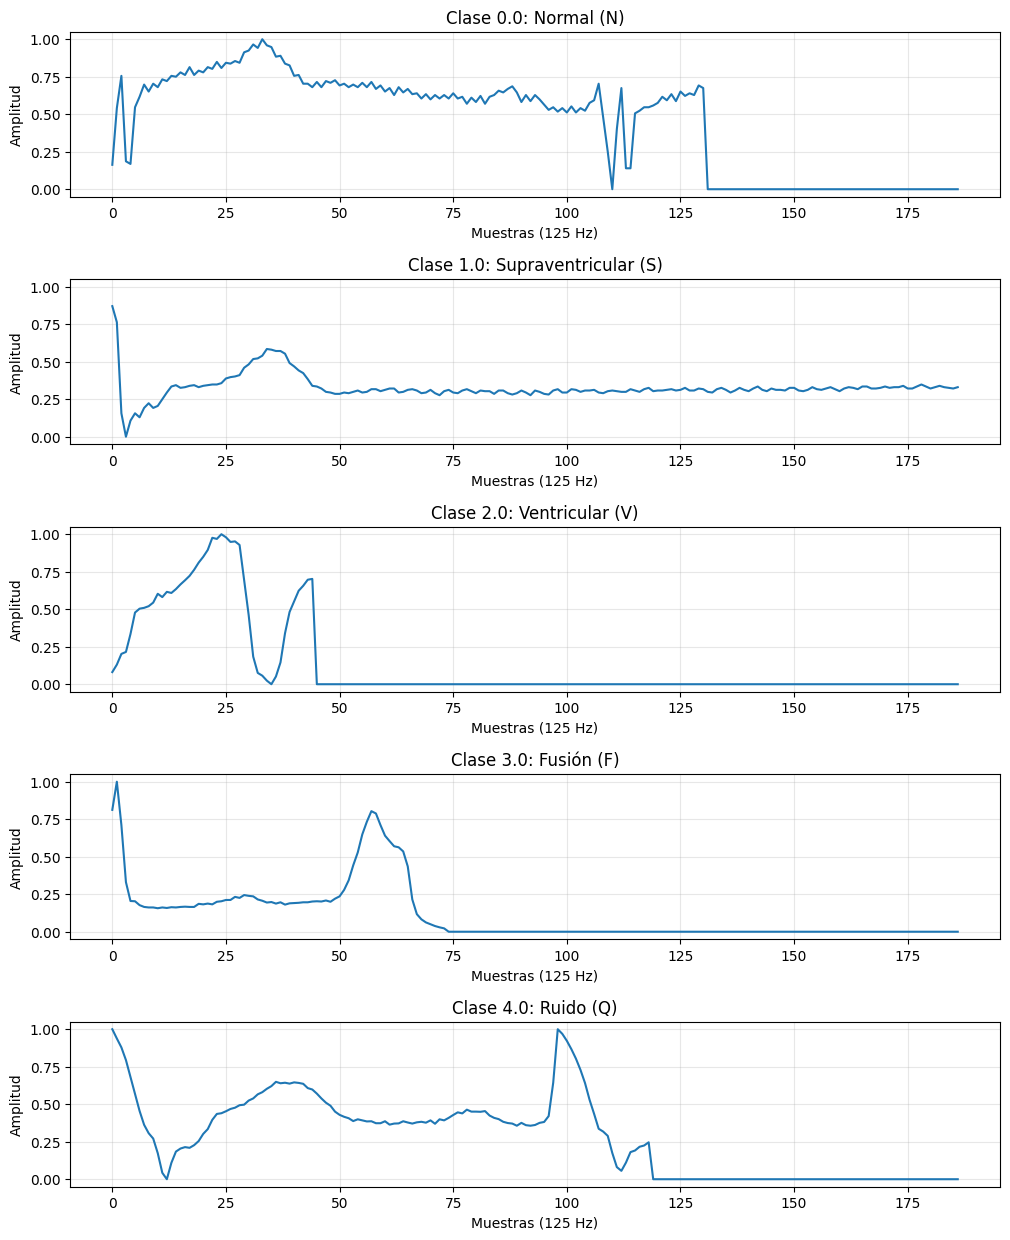

<Figure size 1500x1000 with 0 Axes>

In [11]:
# Creo un diccionario con los datos anteriores
nombres_clases = {ticks[i] : labels[i] for i in range(len(ticks))}

# Creo una figura con 5 filas y 1 columna
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharey=True)
fig.subplots_adjust(hspace=0.5) # espacio entre las gráficas

# Grafico un registro aleatorio de cada clase para ver cómo son las señales
plt.figure(figsize=(15, 10))

for i, clase in enumerate(counts.index):
    registro = df_train[df_train[187] == clase].sample(n=1, random_state=42).iloc[0, :187]
    axs[i].plot(registro.values, label=f'Clase {clase}')
    axs[i].set_title(f"Clase {clase}: {nombres_clases[clase]}")
    axs[i].set_xlabel("Muestras (125 Hz)")
    axs[i].set_ylabel("Amplitud")
    axs[i].grid(alpha=0.3)

plt.show()

#### 2.3 Boxplot para cada clase

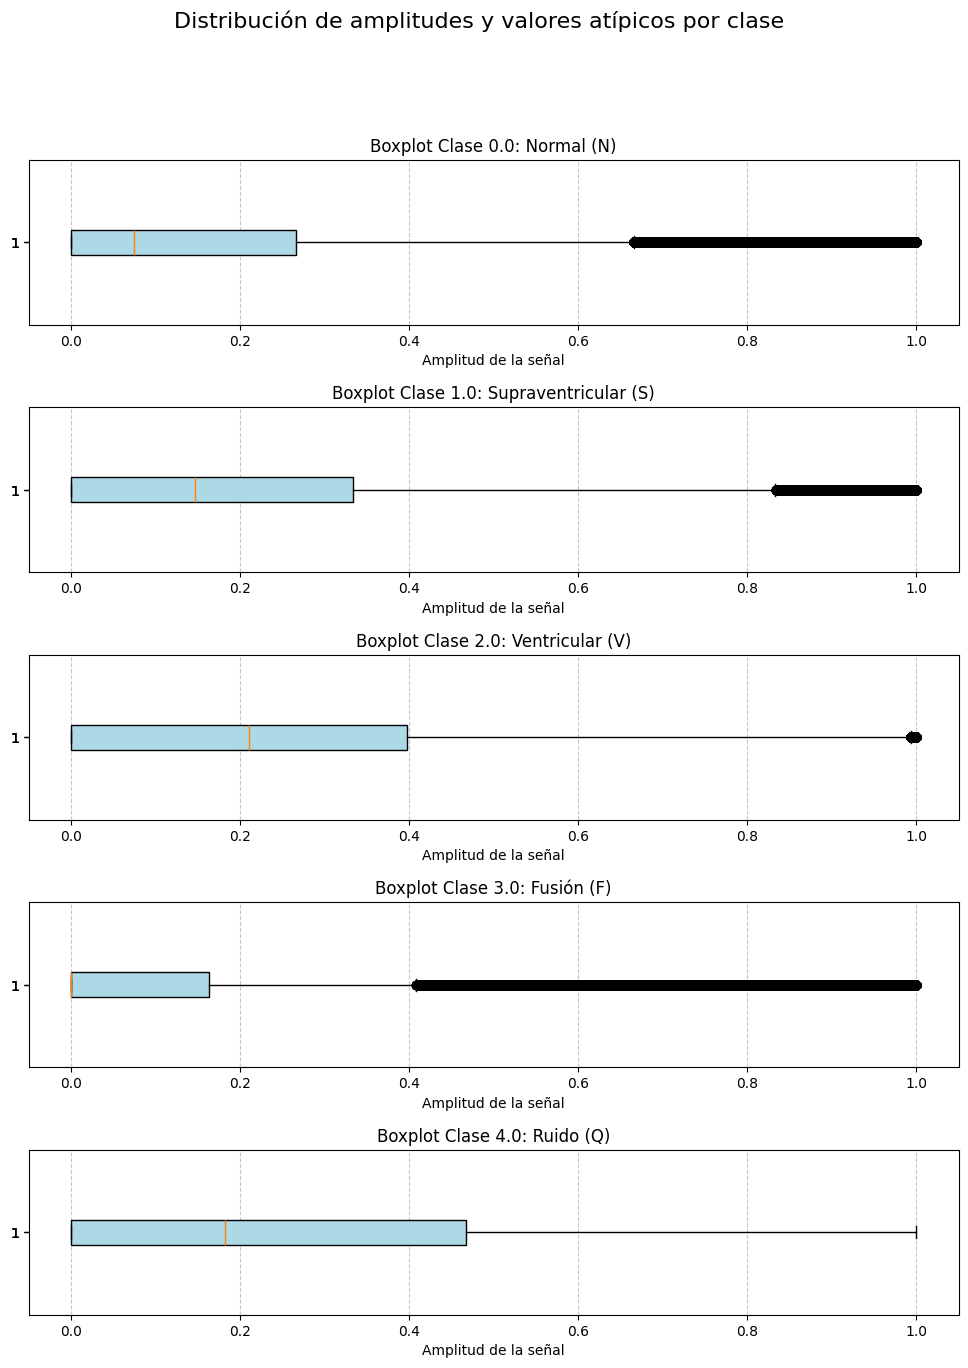

In [12]:
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharey=True)
fig.subplots_adjust(hspace=0.5)


for i, clase in enumerate(counts.index):
    datos_clase = df_train[df_train[187] == clase].iloc[:, :187].values.flatten()

    axs[i].boxplot(datos_clase, vert=False, patch_artist=True,
                   boxprops=dict(facecolor="lightblue"))
    
    axs[i].set_title(f"Clase {clase}: {nombres_clases[clase]}")
    axs[i].set_title(f"Boxplot Clase {clase}: {nombres_clases[clase]}")
    axs[i].set_xlabel("Amplitud de la señal")
    axs[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle("Distribución de amplitudes y valores atípicos por clase", fontsize=16)
plt.show()

#### Histograma de los valores de señal

Anteriormente, se graficó un ejemplo de cada señal para obtener una primera impresión de cada uno de los tipos de las mismas. Aunque es de gran utilidad para un análisis observatorio inicial, aporta más información dentro del mismo tipo de latido observar el latido promedio de cada clase.

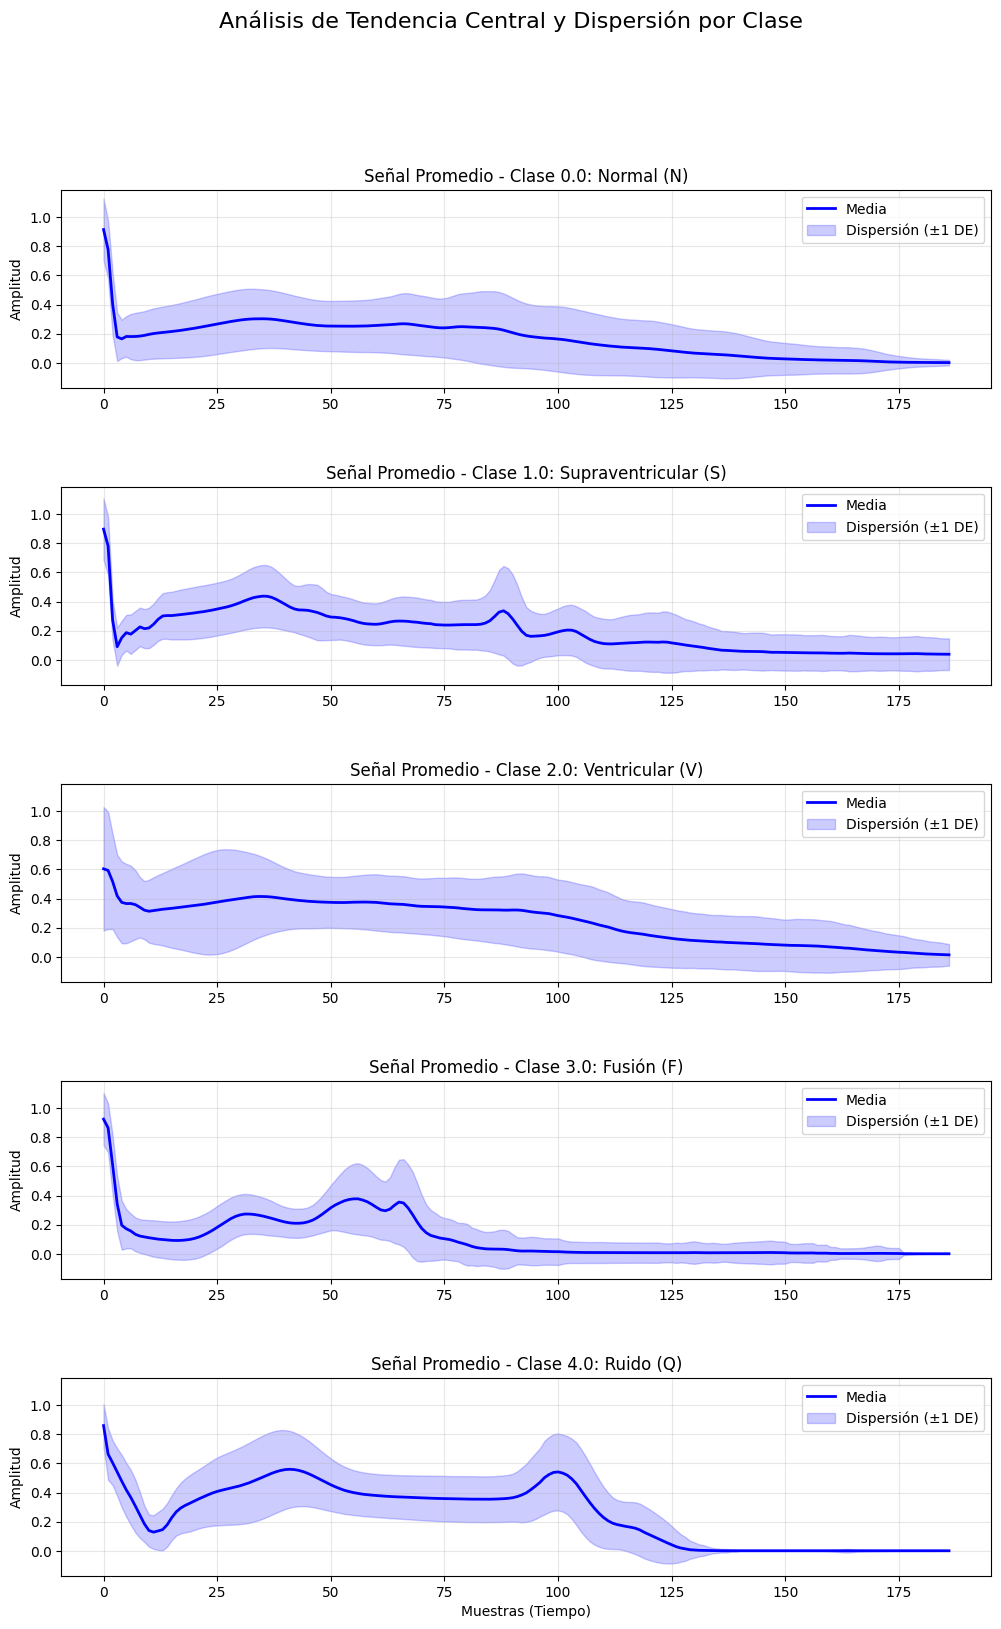

In [13]:

# Creo el grid de 5x1
fig, axs = plt.subplots(5, 1, figsize=(12, 18), sharey=True)
fig.subplots_adjust(hspace=0.5)

x = np.arange(187) # Eje X: de 0 a 186 muestras

for i, clase in enumerate(sorted(df_train[187].unique())):
    # Filtro todos los registros de la clase
    df_clase = df_train[df_train[187] == clase].iloc[:, :187]
    
    # Calculo media y desviacion estandar para cada punto del tiempo
    media = df_clase.mean(axis=0)
    desviacion = df_clase.std(axis=0)
    
    # Grafico la linea de la media
    axs[i].plot(x, media, label="Media", color='blue', linewidth=2)
    
    # Creo el sombreado para visualizar la dispersión
    axs[i].fill_between(x, media - desviacion, media + desviacion, 
                        color='blue', alpha=0.2, label="Dispersión (±1 DE)")
    
    axs[i].set_title(f"Señal Promedio - Clase {clase}: {nombres_clases[clase]}", fontsize=12)
    axs[i].set_ylabel("Amplitud")
    axs[i].grid(alpha=0.3)
    axs[i].legend(loc='upper right')

plt.xlabel("Muestras (Tiempo)")
plt.suptitle("Análisis de Tendencia Central y Dispersión por Clase", fontsize=16)
plt.show()

## Análisis de Componentes principales

Normalizo los datos, ya que aunque los datos ya están entre 0 y 1, el PCA es muy sensible a variaciones de escala entre variables.

In [14]:
# Separo las características (X) de la etiqueta de clase (Y)
X = df_train.iloc[:, :187] # Las 187 muestras de señal
y = df_train.iloc[:, 187] # La columna de la clase

# Hago un escalado de los datos para que cada característica tenga la misma importancia
# a nivel estadístico
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduzco las 187 características a 2 para poder hacer un diagrama de dispersión 2D
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_scaled)

# Calculo la varianza explicada para ver si estos componentes explican la varianza o si me estoy
# perdiendo información valiosa por el camino
var_exp = pca.explained_variance_ratio_
var_total = np.sum(var_exp) * 100

print(f"Varianza explicada por el Componente 1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por el Componente 2: {var_exp[1]*100:.2f}%")
print(f"Varianza total retenida por los 2 componentes: {var_total:.2f}%")



Varianza explicada por el Componente 1: 36.63%
Varianza explicada por el Componente 2: 15.63%
Varianza total retenida por los 2 componentes: 52.26%


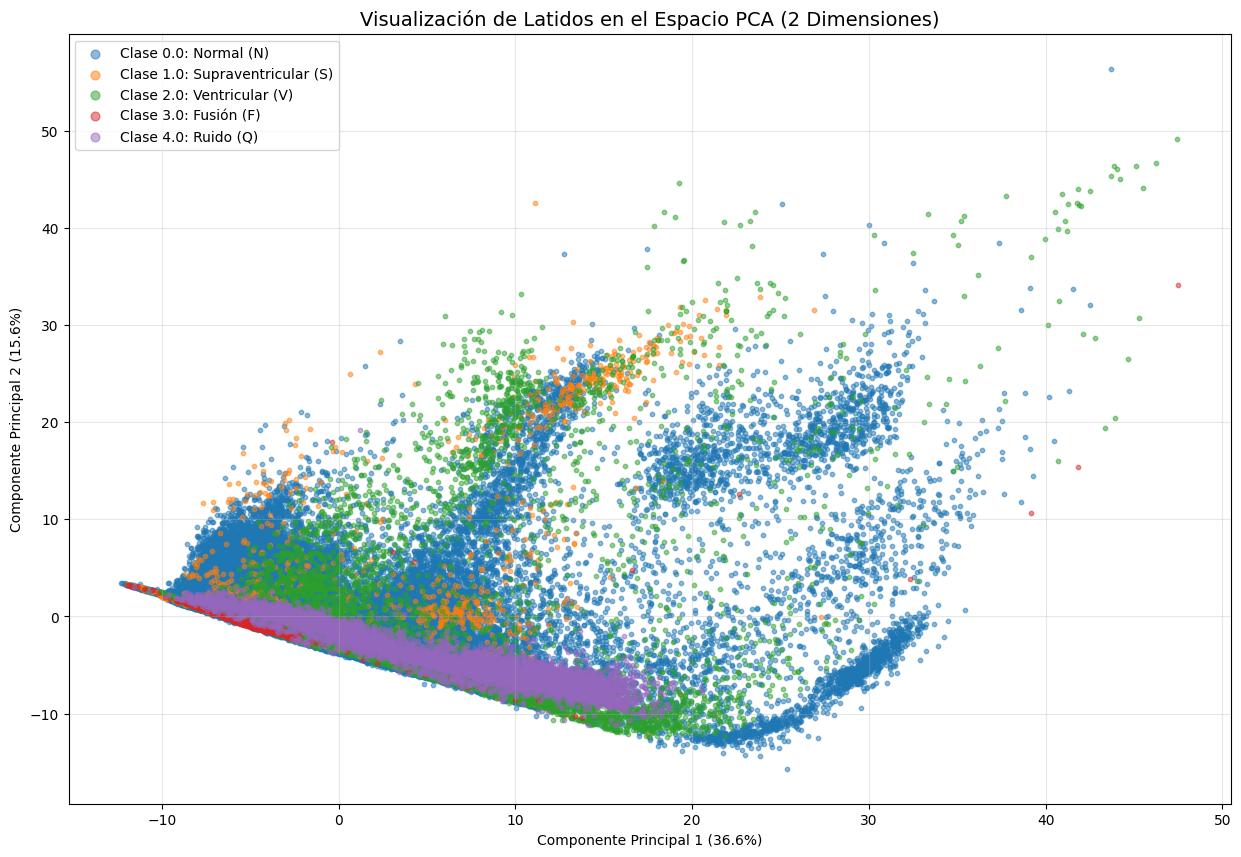

In [15]:
plt.figure(figsize=(15, 10))

for clase in sorted(y.unique()):
    indices = y == clase
    plt.scatter(pca_results[indices, 0],
                pca_results[indices, 1],
                label=f"Clase {clase}: {nombres_clases[clase]}",
                alpha=0.5,
                s=10)
plt.title("Visualización de Latidos en el Espacio PCA (2 Dimensiones)", fontsize=14)
plt.xlabel(f"Componente Principal 1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({var_exp[1]*100:.1f}%)")
plt.legend(markerscale=2)
plt.grid(alpha=0.3)
plt.show()

Como se puede observar en el diagrama de dispersión, existe un gran solapamiento entre las clases, lo que sugiere que los componentes no están estratificando correctamente las clases al identificar aquellos patrones que las diferencian de forma unívoca.

Como la suma de PC1 y PC2 representa el 52,26% de la varianza total, es lógico encontrar un solapamiento, ya que casi el 50% restante de la información necesaria para la discriminación entre clases se encuentra en los componentes restantes.

## 3. Modelos de clasificación

Como a pesar de que existen 5 etiquetas que definen los distintos tipos de latidos se está realmente evaluando la anomalía de los mismos, se procederá a transformar el problema en uno de clasificación binaria, donde la clase 0 (latido normal) se mantendrá y las clases 1 a 4 (latidos anómalos) se agruparán en una única clase 1 (latido anómalo). Estas etiquetas binarias se emplearán para entrenar y evaluar los modelos.

In [ ]:
# Añado la columna al dataset y fijo sus valores binarios en base a las siguientes condiciones
df_train['bin'] = df_train[187].apply(lambda x: 0 if x == 0 else 1)
df_test['bin'] = df_test[187].apply(lambda x: 0 if x == 0 else 1)

X_train = df_train.iloc[:, :187]
X_test = df_test.iloc[:, :187]

# proporciones
print("Distribución binaria en train:")
print(df_train['bin'].value_counts(normalize=True))

Distribución Binaria en Train:
bin
0    0.827729
1    0.172271
Name: proportion, dtype: float64


#### 3.1 Árboles de decisión

Informe de Clasificación:
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97     18118
     Anomalo       0.82      0.88      0.85      3774

    accuracy                           0.94     21892
   macro avg       0.90      0.92      0.91     21892
weighted avg       0.95      0.94      0.95     21892



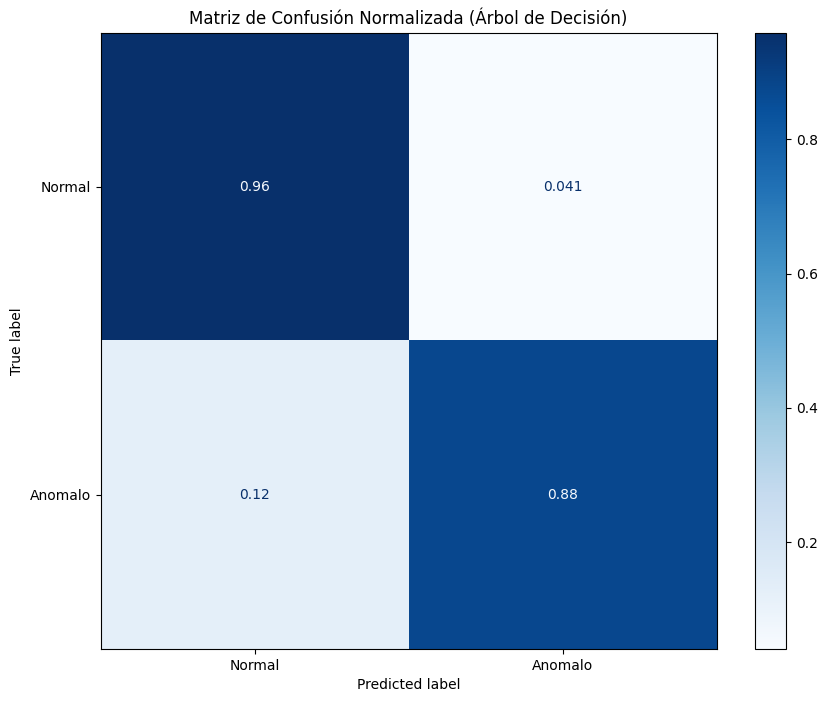

In [23]:
X_train = df_train.iloc[:, :187]
X_test = df_test.iloc[:, :187]

# Definición del Modelo
# Para combatir el desbalance de clases existe el parámetro 'class_weight="balanced"'
clf_tree = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight="balanced")

# Entrenamiento
clf_tree.fit(X_train, df_train['bin'])

# Predicción y Evaluación
y_pred = clf_tree.predict(X_test)

# Hago un reporte de las métricas (Precisión, Recall, F1)
print("Informe de Clasificación:")
print(classification_report(df_test['bin'], y_pred, target_names=['Normal', 'Anomalo']))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(df_test['bin'], y_pred, 
                                        display_labels=['Normal', 'Anomalo'],
                                        cmap='Blues', ax=ax, normalize='true')
plt.title("Matriz de Confusión Normalizada (Árbol de Decisión)")
plt.show()

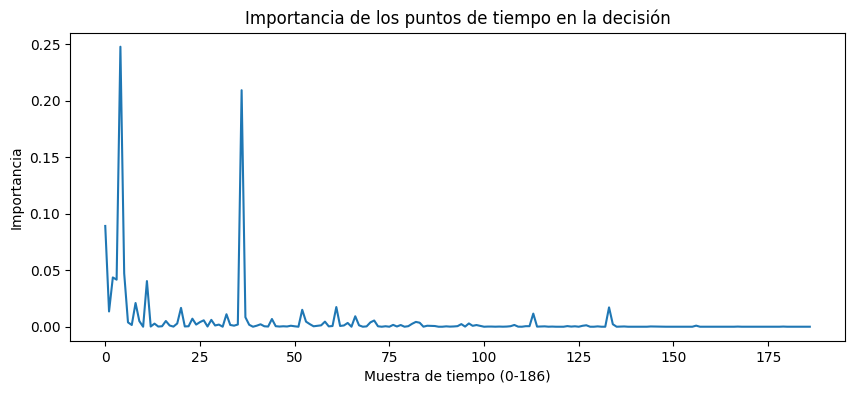

In [24]:
# Compruebo los puntos de la señal más importantes
importances = clf_tree.feature_importances_
plt.figure(figsize=(10, 4))
plt.plot(importances)
plt.title("Importancia de los puntos de tiempo en la decisión")
plt.xlabel("Muestra de tiempo (0-186)")
plt.ylabel("Importancia")
plt.show()

#### 3.2 Clasificador bayesiano

Informe de Clasificación (Naive Bayes):
              precision    recall  f1-score   support

      Normal       0.89      0.88      0.88     18118
     Anomalo       0.45      0.49      0.47      3774

    accuracy                           0.81     21892
   macro avg       0.67      0.68      0.68     21892
weighted avg       0.82      0.81      0.81     21892



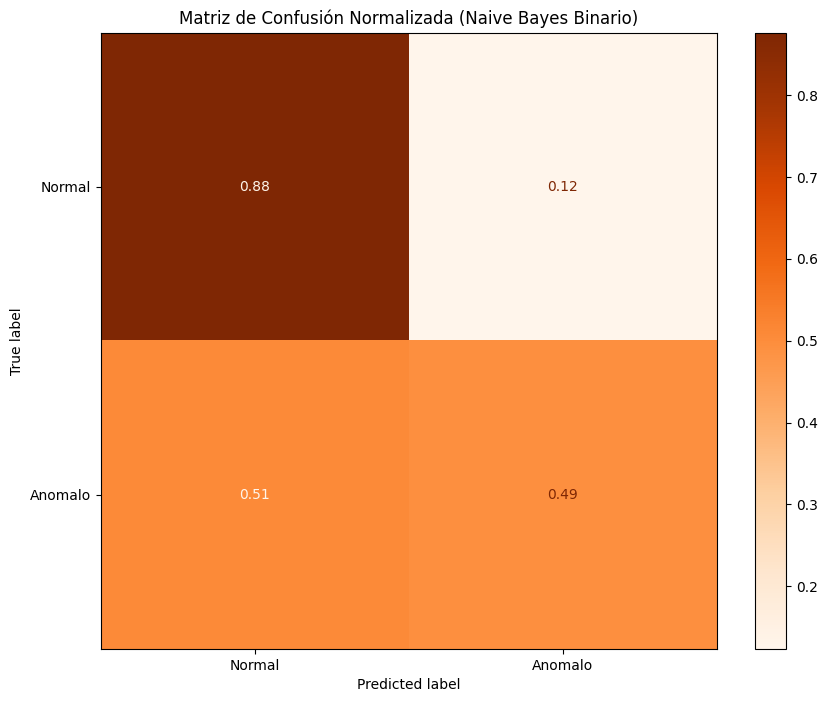

In [25]:
# Definición del Modelo
gnb = GaussianNB()

# Entrenamiento
gnb.fit(X_train, df_train['bin'])

# Predicción
y_pred_nb = gnb.predict(X_test)

# Informe de Resultados
print("Informe de Clasificación (Naive Bayes):")
print(classification_report(df_test['bin'], y_pred_nb, target_names=['Normal', 'Anomalo']))

# Visualización de la matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(df_test['bin'], y_pred_nb, 
                                        display_labels=['Normal', 'Anomalo'],
                                        cmap='Oranges', ax=ax, normalize='true')
plt.title("Matriz de Confusión Normalizada (Naive Bayes Binario)")
plt.show()

## Probabilidades Condicionales y Teorema de Bayes

Una vez empleados los modelos de clasificación, aplico el teorema de bayes para conocer la probabilidad de que un latido sea anómalo dado un cierto patrón de la señal. Para ello, primero identifico aquellos valores
óptimos para el umbral de amplitud y el punto temporal en el que se produce ese umbral.

In [26]:
# Filtro clases
normal = df_train[df_train[187] == 0].iloc[:, :187]
ventricular = df_train[df_train[187] == 2].iloc[:, :187]

# Calculo la diferencia promedio punto a punto
diferencia = ventricular.mean() - normal.mean()

# Encuentro aquel punto donde la ventricular es mucho mayor que la normal
mejor_punto = diferencia.idxmax()
valor_normal = normal[mejor_punto].mean()
valor_ventricular = ventricular[mejor_punto].mean()

# Defino el umbral óptimo
mejor_umbral = (valor_normal + valor_ventricular) / 2

print(f"Amplitud > {mejor_umbral:.2f} en la muestra {mejor_punto}")

Amplitud > 0.30 en la muestra 3


In [27]:
# Defino el patrón X, que es aquel donde la amplitud en la muestra 3 es mayor a 0.3
umbral = 0.3
columna = 3

# Totales
total_registros = len(df_train)
total_clase_0 = len(df_train[df_train[187] == 0])
total_clase_2 = len(df_train[df_train[187] == 2])

# Registros que cumplen el Patrón X
total_con_X = len(df_train[df_train[columna] > umbral])
clase_0_con_X = len(df_train[(df_train[187] == 0) & (df_train[columna] > umbral)])
clase_2_con_X = len(df_train[(df_train[187] == 2) & (df_train[columna] > umbral)])

# Calculo las probabilidades
p_clase_0 = total_clase_0 / total_registros
p_clase_2 = total_clase_2 / total_registros
p_X = total_con_X / total_registros

p_X_dado_clase_0 = clase_0_con_X / total_clase_0
p_X_dado_clase_2 = clase_2_con_X / total_clase_2

print(f"P(Clase 0) = {p_clase_0:.4f}")
print(f"P(Clase 2) = {p_clase_2:.4f}")
print(f"P(X) = {p_X:.4f}")
print(f"P(X | Clase 0) = {p_X_dado_clase_0:.4f}")
print(f"P(X | Clase 2) = {p_X_dado_clase_2:.4f}")

P(Clase 0) = 0.8277
P(Clase 2) = 0.0661
P(X) = 0.2969
P(X | Clase 0) = 0.2260
P(X | Clase 2) = 0.5195
